In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import chromATAC as ca
from chromATAC.integrated import IntData
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.colors as mcolors
from tqdm import tqdm
import warnings
import seaborn as sns
from scipy import stats
import matplotlib.patches as mpatches

In [3]:
path = '/home/icb/mostafa.shahhosseini/data/lupien/'
os.chdir(path)

In [4]:
warnings.simplefilter("ignore", category=pd.errors.ParserWarning)

In [5]:
def get_gaps(df):
    # Ensure the DataFrame is sorted
    df_sorted = df.sort_values(by=['chr', 'start'])

    # Prepare the list to store gap regions
    gaps = []

    # Iterate over the DataFrame
    for chrom, group in df_sorted.groupby('chr'):
        prev_end = None
        for _, row in group.iterrows():
            if prev_end is not None and prev_end < row['start']:
                # Found a gap
                gaps.append([chrom, prev_end, row['start']])
            prev_end = row['end']

    # Create a DataFrame for gaps
    gaps_df = pd.DataFrame(gaps, columns=['chr', 'start', 'end'])
    return gaps_df

In [6]:
tes=[]
for f in os.listdir('./up-down-TEs/'):
    if f.endswith('s.matrix'):
        with open(os.path.join('./up-down-TEs/', f)) as t:
            tes.extend(t.readline().split('\t'))

In [8]:
tes_dir = './merged.bedfiles/'
cotes_dir = './cotes.1000/'

In [9]:
TEs = np.array([i.split('.')[0] for i in os.listdir(tes_dir) if i.endswith('.bed')])
COTEs = np.array([i.split('.')[0] for i in os.listdir(cotes_dir) if i.endswith('.bed')])

In [10]:
ind = IntData()

In [10]:
ind.add_layer("TEs", 
              tes_dir, 
              index_mapper=lambda x: x.split("_Merged.bed")[0], 
              resolutions=1e06)

loading files from: ./merged.bedfiles/


100%|██████████| 976/976 [00:40<00:00, 24.21it/s]


In [12]:
ind.add_layer("CoTEs", 
              cotes_dir, 
              index_mapper=lambda x: x.split("_Merged.bed")[0], 
              resolutions=1e06)

loading files from: ./cotes.1000//


100%|██████████| 460/460 [00:10<00:00, 44.41it/s]


In [11]:
noclass = ["Simple_repeat","Satellite","rRNA","snRNA","srpRNA","scRNA","RNA","Low_complexity","Unknown","tRNA"]

_ = pd.read_csv('./repeat_masker.tsv', sep='\t')
te_meta = _.loc[:, ['repName', 'repClass', 'repFamily']]
te_meta = te_meta[te_meta['repClass'].map(lambda x: x not in noclass)]

In [12]:
te_meta = te_meta.groupby('repName').sample()

In [13]:
te_n_elements = pd.read_csv('./counts_tes.tsv')
cote_n_elments = pd.read_csv('./counts_cotes.1000.tsv')

te_n_elements['Filename'] = te_n_elements['Filename'].map(lambda x: x.split('_', 2)[-1])
te_df = te_meta.merge(te_n_elements, left_on='repName', right_on='Filename', how='inner')
te_df = te_df.set_index('repName')

In [14]:
cote_n_elments['Filename'] = cote_n_elments['Filename'].map(lambda x: x.split('_', 2)[-1])
cote_df = te_meta.merge(cote_n_elments, left_on='repName', right_on='Filename', how='inner')
cote_df = cote_df.set_index('repName')

In [15]:
te_df['has_CoTE'] = te_df.index.map(lambda x: x in cote_df.index.values)

In [16]:
for t in TEs:
    df = pd.read_csv(str(os.path.join(tes_dir,t))+ '.merged.bed', sep='\t', names=['chr', 'start', 'end'])
    df['length']=df['end']-df['start']
    te_df.loc[t.split('_', 2)[-1], 'mean_length']=df['length'].mean()
        # Ensure data is sorted by chromosome and start position
    df.sort_values(by=['chr', 'start'], inplace=True)
    
    # Calculate differences between the end of one region and the start of the next
    # Shift the 'start' column up to align with the 'end' of the previous region
    df['prev_end'] = df['end'].shift(1)
    
    # Filter out the first entry of each chromosome as it has no preceding region
    df = df[df['chr'] == df['chr'].shift(1)]
    
    # Calculate interval lengths
    df['interval_length'] = df['start'] - df['prev_end']
    
    # Calculate mean of the interval lengths
    mean_interval_length = df['interval_length'].mean()
    te_df.loc[t.split('_', 2)[-1], 'mean_te_interval_length']=df['length'].mean()

In [17]:
cote_df = te_df[te_df['has_CoTE']].copy()

In [18]:
for t in COTEs:
    df = pd.read_csv(str(os.path.join(cotes_dir,t))+ '.merged.cotes.bed', sep='\t', names=['chr', 'start', 'end'])
    df['length'] = df['end']-df['start']
    cote_df.loc[t.split('_', 2)[-1], 'mean_cote_length']=df['length'].mean()
    df.sort_values(by=['chr', 'start'], inplace=True)
    
    # Calculate differences between the end of one region and the start of the next
    # Shift the 'start' column up to align with the 'end' of the previous region
    df['prev_end'] = df['end'].shift(1)
    
    # Filter out the first entry of each chromosome as it has no preceding region
    df = df[df['chr'] == df['chr'].shift(1)]
    
    # Calculate interval lengths
    df['interval_length'] = df['start'] - df['prev_end']
    
    # Calculate mean of the interval lengths
    cote_df.loc[t.split('_', 2)[-1], 'mean_cote_interval_length']=df['interval_length'].mean()

## Evolutionary Age

In [19]:
kimura = pd.read_csv('./kimura_distance_hg38.tsv', sep='\t')

In [20]:
te_df = te_df.merge(kimura, right_on='Repeat', left_on='Filename')

In [111]:
te_df

,repname,Superfamily,COTE,n_elements,n_clusters,mean_length,mean_dist_length,Repeat_x,Class_x,Kimura%_x,Repeat_y,Class_y,Kimura%_y
0,LTR36,ERV1,False,504,0.0,379.301587,5.718405e+06,LTR36,LTR/ERV1,17.83,LTR36,LTR/ERV1,17.83
1,LTR16A1,ERV3,True,2726,39.0,267.259354,1.057406e+06,LTR16A1,LTR/ERVL,30.61,LTR16A1,LTR/ERVL,30.61
2,Tigger12,Transposons,False,970,0.0,195.914433,2.931965e+06,Tigger12,DNA/TcMar-Tigger,32.22,Tigger12,DNA/TcMar-Tigger,32.22
3,L1M,LINE1,False,749,0.0,103.778371,3.866368e+06,L1M,LINE/L1,33.12,L1M,LINE/L1,33.12
4,UCON27,SINE2,False,100,0.0,214.470000,2.053928e+07,UCON27,Unknown,30.48,UCON27,Unknown,30.48
...,...,...,...,...,...,...,...,...,...,...,...,...,...
961,LTR43,ERV1,False,467,0.0,360.927195,5.632299e+06,LTR43,LTR/ERV1,14.24,LTR43,LTR/ERV1,14.24
962,LTR75B,ERV3,False,202,0.0,299.633663,1.090485e+07,LTR75B,LTR/ERVL,26.24,LTR75B,LTR/ERVL,26.24
963,MER90a,ERV1,True,1273,27.0,323.063629,2.266307e+06,MER90a,LTR/ERV1,27.78,MER90a,LTR/ERV1,27.78
964,MER50-int,ERV1,False,515,0.0,799.271845,4.412513e+06,MER50-int,LTR/ERV1,17.54,MER50-int,LTR/ERV1,17.54


/tmp/ipykernel_3709072/1639716929.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=te_df['Kimura%'], y=te_df['has_CoTE'],orient='h', palette=["orange", "steelblue"], linecolor='grey')


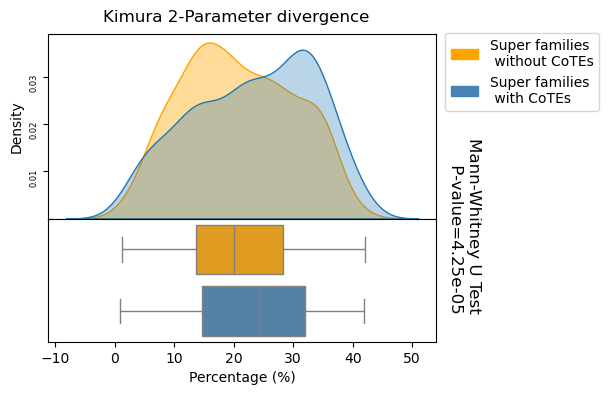

In [32]:
fig, axs = plt.subplots(2, 1, figsize=(5, 4), sharex=True, height_ratios=[3, 2])
sns.kdeplot(te_df[~te_df['has_CoTE']].loc[:,'Kimura%'].values, fill=True, alpha=0.4, color='orange', ax=axs[0])
sns.kdeplot(te_df[te_df['has_CoTE']].loc[:,'Kimura%'].values, fill=True, alpha=0.3, ax=axs[0])
plt.subplots_adjust(hspace=0)
sns.boxplot(x=te_df['Kimura%'], y=te_df['has_CoTE'],orient='h', palette=["orange", "steelblue"], linecolor='grey')
axs[0].set_yticks([0.01, 0.02, 0.03])
axs[1].set_yticklabels([])
orange_patch = mpatches.Patch(color='orange', label='Super families \n without CoTEs')
blue_patch = mpatches.Patch(color='steelblue', label='Super families \n with CoTEs')
fig.legend(handles=[orange_patch, blue_patch], loc='upper right', bbox_to_anchor=(1.24,.9))
axs[0].tick_params(axis='y', labelsize=6, rotation=90)
axs[1].tick_params(axis='y', labelsize=6, length=0)
axs[1].set_ylabel('')
# Create a second y-axis sharing the same x-axis
fig.text(0.99, 0.4, 'Mann-Whitney U Test\n P-value=4.25e-05', fontdict={'fontsize':12},  va='center', ha='right', rotation=270)

plt.suptitle('Kimura 2-Parameter divergence', y=0.94)
plt.xlabel('Percentage (%)')
plt.show()
fig.savefig('./figures/fig1/c-kimura.png', dpi=300, bbox_inches='tight')
fig.savefig('./figures/fig1/c-kimura.svg', dpi=300, bbox_inches='tight')

In [89]:
# Assuming 'df' is your DataFrame and 'signal' is the column you want to test
# Replace 'signal' with the name of your signal column

# Perform Shapiro-Wilk test
shapiro_test = stats.shapiro(te_df['Kimura%'])

# shapiro_test will return a tuple (test statistic, p-value)
print("Shapiro-Wilk test statistic:", shapiro_test[0])
print("P-value:", shapiro_test[1])

# Interpretation
if shapiro_test[1] > 0.05:
    print("The data is likely normally distributed.")
else:
    print("The data is likely not normally distributed.")

Shapiro-Wilk test statistic: 0.9744425415992737
P-value: 5.349389767955737e-12
The data is likely not normally distributed.
